# 02 - USGS Download and Band Visualizations
Downloads Landsat from USGS M2M only, extracts B2/B3/B4/B5, and visualizes all bands + RGB composite.

In [1]:
import json
import os
import glob
import tarfile
import time
from datetime import date
import requests
import numpy as np
import matplotlib.pyplot as plt
import rasterio

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
config_path = os.path.join(PROJECT_ROOT, 'data', 'config.json')
with open(config_path, 'r', encoding='utf-8') as f:
    cfg = json.load(f)

BBOX = cfg['bbox']
LANDSAT_DIR = cfg['paths']['landsat_dir']
FIG_DIR = cfg['paths']['fig_dir']

USGS_USERNAME = os.getenv('USGS_USERNAME', '')
USGS_APP_TOKEN = os.getenv('USGS_APP_TOKEN', '')
if not USGS_USERNAME or not USGS_APP_TOKEN:
    raise ValueError('Set USGS_USERNAME and USGS_APP_TOKEN in environment before running.')

In [3]:
USGS_BASE = 'https://m2m.cr.usgs.gov/api/api/json/stable'
DATASET = 'landsat_ot_c2_l2'
REQUIRED_BANDS = [2, 3, 4, 5]

def usgs_call(endpoint, payload=None, api_key=None):
    headers = {'Content-Type': 'application/json'}
    if api_key:
        headers['X-Auth-Token'] = api_key
    r = requests.post(f"{USGS_BASE}/{endpoint}", json=payload or {}, headers=headers, timeout=120)
    r.raise_for_status()
    body = r.json()
    if body.get('errorCode'):
        raise RuntimeError(f"USGS {endpoint} failed: {body.get('errorCode')} - {body.get('errorMessage')}")
    return body.get('data')

def normalize_options(raw):
    if isinstance(raw, list):
        return raw
    if isinstance(raw, dict):
        if isinstance(raw.get('downloadOptions'), list):
            return raw['downloadOptions']
        for v in raw.values():
            if isinstance(v, list):
                return v
    return []

def extract_urls(raw):
    urls = []
    if isinstance(raw, dict):
        for k in ['availableDownloads', 'requestedDownloads', 'preparingDownloads', 'newRecords', 'duplicateProducts']:
            entries = raw.get(k, [])
            if isinstance(entries, list):
                for e in entries:
                    if isinstance(e, dict) and e.get('url'):
                        urls.append(e['url'])
    return urls

In [4]:
api_key = usgs_call('login-token', {'username': USGS_USERNAME, 'token': USGS_APP_TOKEN})

search_payload = {
    'datasetName': DATASET,
    'maxResults': 25,
    'startingNumber': 1,
    'sortOrder': 'DESC',
    'sceneFilter': {
        'spatialFilter': {
            'filterType': 'mbr',
            'lowerLeft': {'latitude': BBOX[1], 'longitude': BBOX[0]},
            'upperRight': {'latitude': BBOX[3], 'longitude': BBOX[2]}
        },
        'acquisitionFilter': {'start': '2022-01-01', 'end': date.today().isoformat()},
        'cloudCoverFilter': {'min': 0, 'max': 20, 'includeUnknown': False}
    }
}

scenes_data = usgs_call('scene-search', search_payload, api_key=api_key)
scenes = scenes_data.get('results', []) if isinstance(scenes_data, dict) else []
if not scenes:
    raise RuntimeError('No scene found for AOI.')

scene = scenes[0]
entity_id = scene.get('entityId')
display_id = scene.get('displayId') or entity_id
print('Selected scene:', display_id)

raw_options = usgs_call('download-options', {'datasetName': DATASET, 'entityIds': [entity_id]}, api_key=api_key)
options = [o for o in normalize_options(raw_options) if isinstance(o, dict) and o.get('available')]
if not options:
    raise RuntimeError('No available download option for selected scene.')

choice = options[0]
for o in options:
    name = (o.get('productName') or '').lower()
    if 'bundle' in name or ('level-2' in name and 'science' in name):
        choice = o
        break
product_id = choice.get('id') or choice.get('productId')

label = f'landsat_{entity_id}_{int(time.time())}'
request_payload = {
    'downloads': [{'entityId': entity_id, 'productId': product_id}],
    'label': label,
    'datasetName': DATASET
}
req_data = usgs_call('download-request', request_payload, api_key=api_key)
urls = extract_urls(req_data if isinstance(req_data, dict) else {})

if not urls:
    for _ in range(18):
        time.sleep(10)
        ret_data = usgs_call('download-retrieve', {'label': label}, api_key=api_key)
        urls = extract_urls(ret_data if isinstance(ret_data, dict) else {})
        if urls:
            break
if not urls:
    raise RuntimeError('USGS did not return downloadable URL in time.')

download_url = urls[0]
tar_path = os.path.join(LANDSAT_DIR, f'{display_id}.tar')
if not os.path.exists(tar_path):
    with requests.get(download_url, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(tar_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    f.write(chunk)

scene_dir = os.path.join(LANDSAT_DIR, display_id)
os.makedirs(scene_dir, exist_ok=True)
with tarfile.open(tar_path, 'r:*') as tar:
    tar.extractall(scene_dir)

meta = {
    'display_id': display_id,
    'entity_id': entity_id,
    'scene_dir': scene_dir,
    'acquisition_date': scene.get('acquisitionDate'),
    'cloud_cover': scene.get('cloudCover')
}
meta_path = os.path.join(LANDSAT_DIR, 'scene_metadata.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)
print('Scene extracted to:', scene_dir)
print('Metadata saved:', meta_path)
usgs_call('logout', {}, api_key=api_key)

Selected scene: LC09_L2SP_018030_20260422_20260423_02_T1


/tmp/ipykernel_17607/338077874.py:74: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(scene_dir)


Scene extracted to: /content/lulc_notebook_project/data/landsat/LC09_L2SP_018030_20260422_20260423_02_T1
Metadata saved: /content/lulc_notebook_project/data/landsat/scene_metadata.json


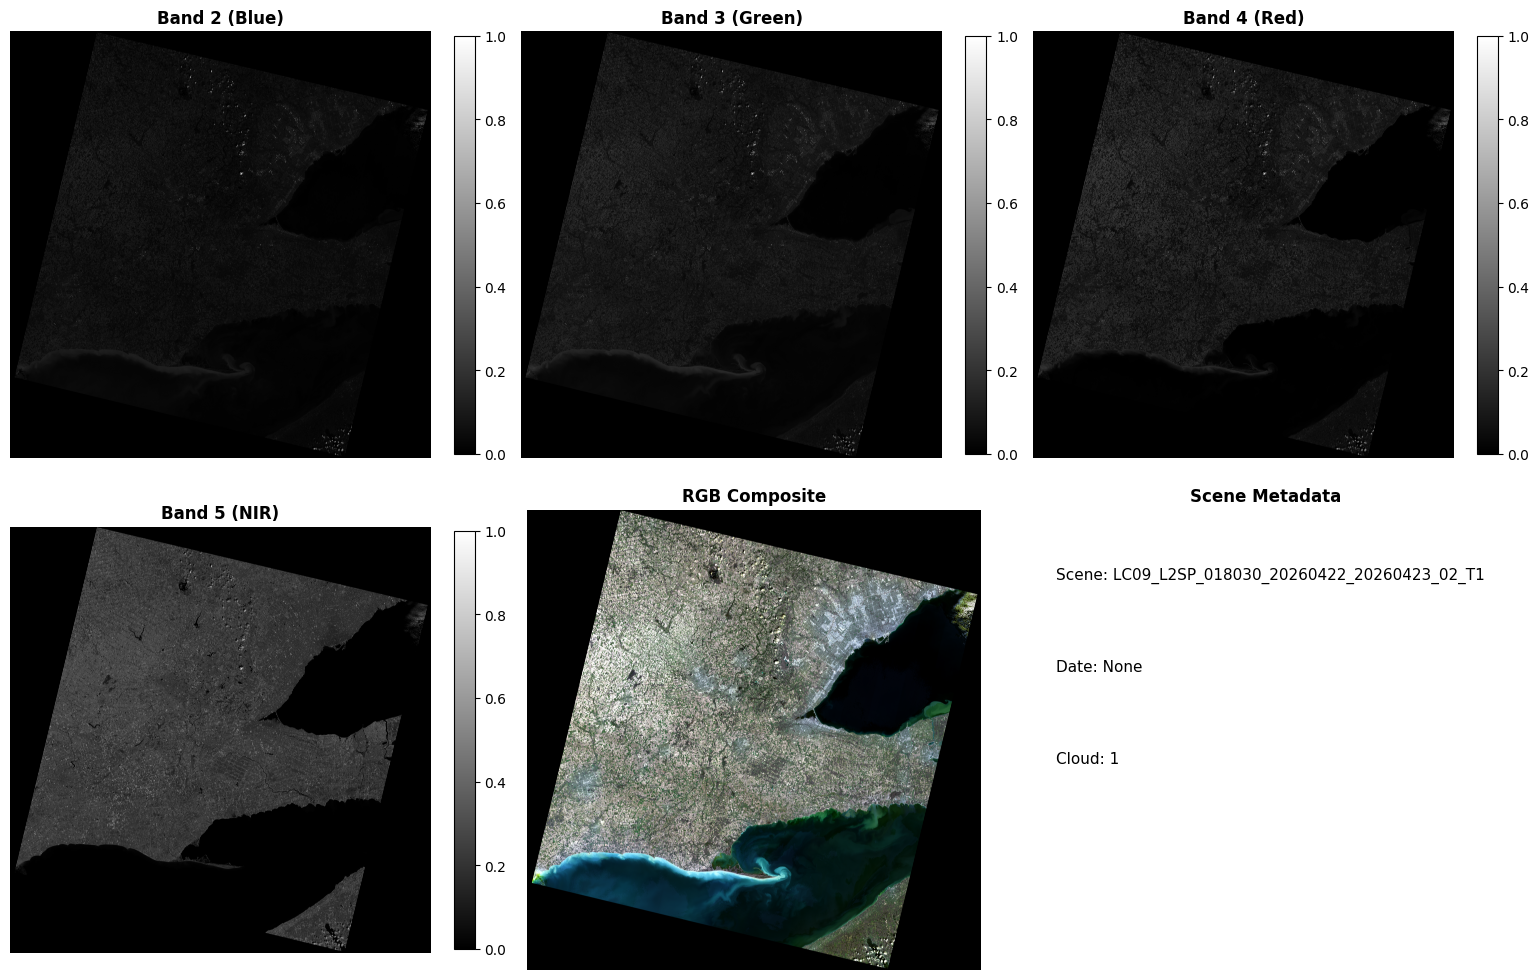

Saved: /content/lulc_notebook_project/outputs/figures/02_bands_and_rgb.png


In [5]:
# Visualize all required bands and RGB composite
with open(os.path.join(LANDSAT_DIR, 'scene_metadata.json'), 'r', encoding='utf-8') as f:
    meta = json.load(f)
scene_dir = meta['scene_dir']
display_id = meta['display_id']

band_paths = {}
for b in REQUIRED_BANDS:
    matches = glob.glob(os.path.join(scene_dir, '**', f'*_SR_B{b}.TIF'), recursive=True)
    if matches:
        band_paths[b] = matches[0]
if len(band_paths) < 4:
    raise RuntimeError('Could not find all required bands in extracted scene.')

SCALE_FACTOR = 0.0000275
OFFSET = -0.2
bands = {}
for b, p in band_paths.items():
    with rasterio.open(p) as src:
        arr = src.read(1).astype('float32')
    arr = np.clip(arr * SCALE_FACTOR + OFFSET, 0, 1)
    bands[b] = arr

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
titles = {2: 'Band 2 (Blue)', 3: 'Band 3 (Green)', 4: 'Band 4 (Red)', 5: 'Band 5 (NIR)'}
positions = [(0, 0), (0, 1), (0, 2), (1, 0)]
for b, (r, c) in zip([2, 3, 4, 5], positions):
    ax = axes[r, c]
    im = ax.imshow(bands[b], cmap='gray')
    ax.set_title(titles[b], fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.045)

def norm(x):
    lo, hi = np.percentile(x[x > 0], [2, 98])
    return np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)

rgb = np.dstack([norm(bands[4]), norm(bands[3]), norm(bands[2])])
axes[1, 1].imshow(rgb)
axes[1, 1].set_title('RGB Composite', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].axis('off')
axes[1, 2].text(0.05, 0.85, f'Scene: {display_id}', fontsize=11)
axes[1, 2].text(0.05, 0.65, f'Date: {meta.get("acquisition_date")}', fontsize=11)
axes[1, 2].text(0.05, 0.45, f'Cloud: {meta.get("cloud_cover")}', fontsize=11)
axes[1, 2].set_title('Scene Metadata', fontweight='bold')

plt.tight_layout()
out_path = os.path.join(FIG_DIR, '02_bands_and_rgb.png')
plt.savefig(out_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out_path)